### Kelly Sticca
##### February 9th, 2026 (Extension granted)
# LAB 2 - (just after day 5 tutorial)
### My apologies, I had a really hard time configuring this assignment. With the limited time I had available catching up from absences, I finally decided to utilize the day 5 tutorial environment because I just kept having so many errors while handling the set up of the lab. Please skip ahead to the second section labled "LAB 2". 

# Day 5: finding samples of SDSS-V spectra with allspec

From this notebook, we will figure out how to use the allspec database on SkyServer compute to: 

--find a spectrum for objects within a certain distance on the sky to a target location

--find objects matching signal-to-noise and redshift thresholds

--find objects with a certain number of observed spectra

Then for the lab, you will adapt this code to measure C IV lines over time for a quasar with 10+ observed spectra and make plots of their properties

In [1]:
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import astropy.io.fits
import astropy.coordinates
import fitsio
import sdss_access

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.size'] = 14

## Do not edit the following code adapted from the SDSS allspec tutorial

In [2]:
sdss_path = sdss_access.path.Path(release='dr19', verbose=True)
access = sdss_access.Access(release='dr19', verbose=True)

In [3]:
allspec_file = sdss_path.full('allspec', vers='1.0.1', release='dr19')

if not sdss_path.exists('',full=allspec_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('allspec', vers='1.0.1', release='dr19')
    access.set_stream()
    access.commit()
print(allspec_file)

/home/idies/workspace/sdss_sas/dr19/spectro/allspec/1.0.1/allspec-dr19-1.0.1.fits.gz


In [4]:
# this step is slow give it time the allspec file is enormous
allspec_hdus = astropy.io.fits.open(allspec_file)
allspec = np.array(allspec_hdus[1].data)

## 1. Matching by position to `allspec`

Find a sky position from e.g. your exploration of the sky using SkyServer on Monday and enter its RA and Dec below in degrees

In [5]:
center_ra = [229.52556]                                           ##
center_dec = [42.745853]                                          ##
center_coords = astropy.coordinates.SkyCoord(center_ra, center_dec, unit='deg', frame='icrs')

unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]
unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

indx, sep, s3 = unique_coords.match_to_catalog_sky(center_coords)
sep = sep.value   # avoid units nonsense ("value" is in deg in this case)

best_match_idx = indx[np.argmin(sep)]                             ## testing the index
closest_distance = np.min(sep)                                    ##

print(f"Success! Found the galaxy at index: {best_match_idx}")    ## print the result
print(f"The distance from target is: {closest_distance} degrees") ##

Success! Found the galaxy at index: 0
The distance from target is: 0.0 degrees


### modify the following code to find all objects within 0.5 degrees of the target location

In [6]:
isep = sep < 0.5 ## modified to find objects within 0.5 degrees

# no need to modify, finding sdss_ids and index locations of matches
match_indx = unique_indx[isep]
sdss_id = allspec['sdss_id'][match_indx]

print(f"Found {len(sdss_id)} objects within 0.5 degrees of the galaxy.") ## testing to see how many objects were found

Found 227 objects within 0.5 degrees of the galaxy.


### 2. get the list of files for one spectrum per matching object

In [7]:
### find one spectrum per matching object

matching_spectra = allspec[match_indx]                            

# Finding the index, one spectrum per object
# np.unique: list of unique IDs, and index where they first appear
unique_ids, first_appearance_rows = np.unique(matching_spectra['sdss_id'], return_index=True)

# Using those row numbers to grab one spectrum per object
one_spec_per_object = matching_spectra[first_appearance_rows]

print(f"Total spectra found: {len(matching_spectra)}")
print(f"One spectrum per object: {len(one_spec_per_object)}")

Total spectra found: 227
One spectrum per object: 227


### 3. now instead of matching by location let's find objects using redshift and signal-to-noise cuts

In [8]:
# this step loads data from the spall file and so also takes a little bit to run
spall_file = sdss_path.full('spAll', run2d='v6_1_3')

if not sdss_path.exists('',full=spall_file):
    # if the file does not exist locally, this code will download the data.
    access.remote()
    access.add('spAll', run2d='v6_1_3')
    access.set_stream()
    access.commit()
print(spall_file)

spall_columns = ['SDSS_ID', 'CARTON_TO_TARGET_PK', 'MJD', 'CLASS', 'SUBCLASS', 'Z', 'ZWARNING', 'SN_MEDIAN_ALL', 'PSFMAG']
spall = fitsio.read(spall_file, columns=spall_columns)

/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spAll-v6_1_3.fits.gz


Here spall['Z'] contains redshifts, spall['PSFMAG'] contains ugriz magnitudes for the spectrum, and spall['SN_MEDIAN_ALL'] contains a summary signal to noise

#### write a condition e.g. using a logical expression np.where to find all objects where C IV should be visible in the observed spectrum, where the g-band magnitude (spall['PSFMAG'][:,1]) is less than 18, and where the signal-to-noise is greater than 20

In [9]:
# 1. Redshift high enough to see C IV (typically z > 1.5)
# 2. G-band magnitude < 18 (spall['PSFMAG'][:,1] < 18)
# 3. Signal-to-Noise > 20 (spall['SN_MEDIAN_ALL'] > 20)

# Link each condition with "&"
condition = (spall['Z'] > 1.5) & (spall['PSFMAG'][:,1] < 18) & (spall['SN_MEDIAN_ALL'] > 20)

indx = np.where(condition)
sdssid_sample = spall['SDSS_ID'][indx]

print(f"Found {len(sdssid_sample)} objects that meet all three criteria.")

Found 950 objects that meet all three criteria.


In [10]:
# for some list of matching objects, let's find those with many spectra
for sdssid in sdssid_sample:
    iallmatch = np.where(allspec['sdss_id'] == sdssid)[0]
    files = allspec['allspec_id'][iallmatch]
    nfiles = len(files)
    
    ### add code here to leave the loop if an object has more than 3 spectra
    if nfiles > 3:
        # store the current ID so we can print it later
        current_sdss_id = sdssid 
        break # "break" exits the loop immediately
        
print(f"Found object: {current_sdss_id}")
print(f"Number of spectra: {nfiles}")
print(f"File IDs: {files}")

Found object: 70057992
Number of spectra: 100
File IDs: [b'sdss4-apo-boss-v5_13_2-6369-56217-0216'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59146-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015002-59146-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59163-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015002-59163-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59164-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015002-59164-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59167-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015002-59167-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59189-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59190-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59192-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015000-59193-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015002-59195-4375921291-70057992'
 b'sdss5-apo-boss-daily-v6_1_3-015002-59197-4375921291-7

#### 4. Looking at the spectra (code from DR19 allspec tutorial, hopefully shouldn't need to be modified?)

We can track down the spectra on disk quite easily. The `sas_url` tells us the path. We just need to change the root of the tree to a local file path as follows.

If the data don't already exist on disk (e.g., if you're not running this notebook on SciServer), we can download the data easily with `sdss_access`

In [11]:
url_root = 'https://data.sdss.org/sas'
local_root = os.getenv('SAS_BASE_DIR')
spectrum_files = list()
download_files = list()

for p in allspec["sas_url"][iallmatch]:
    local_path = p.decode().replace(url_root, local_root)
    spectrum_files.append(local_path)
    if not os.path.exists(local_path):
        download_files.append(local_path)

if len(download_files) > 0:
    print("fetching files, please stand by")
    access.remote()
    for local_path in download_files:
        access.add_file(local_path, input_type='filepath')

    access.set_stream()

    # disable follow_symlinks
    access.commit(follow_symlinks=False)

Here then are the paths in the local SAS directory structure:

In [12]:
for f in spectrum_files:
    print(f)

/home/idies/workspace/sdss_sas/dr17/eboss/spectro/redux/v5_13_2/spectra/lite/6369/spec-6369-56217-0216.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015000/59146/spec-015000-59146-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015002/59146/spec-015002-59146-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015000/59163/spec-015000-59163-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015002/59163/spec-015002-59163-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015000/59164/spec-015000-59164-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015002/59164/spec-015002-59164-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/015000/59167/spec-015000-59167-4375921291.fits
/home/idies/workspace/sdss_sas/dr19/sp

We can open one of the BOSS files up to see what it has in it. We'll first just look at what the HDUs are called.

In [13]:
spec_hdulist = astropy.io.fits.open(spectrum_files[0])

In [14]:
for ihdu, spec_hdu in enumerate(spec_hdulist):
    if('extname' in spec_hdu.header):
        print(spec_hdu.header['extname'])
    else:
        print("HDU{i}".format(i=ihdu))

HDU0
COADD
SPALL
SPZLINE


It looks like "COADD" actuall has the spectrum. This is a table, and the columns have the fluxes, wavelengths, masks, etc. Really you should look at the data model at: https://data.sdss.org/datamodel/files/BOSS_SPECTRO_REDUX/RUN2D/spectra/PLATE4/spec.html

In [15]:
coadd = np.array(spec_hdulist['COADD'].data)
coadd_header = spec_hdulist['COADD'].header

Now we can plot and label our plot:

Text(0, 0.5, '$f_\\lambda$ \\rm ($10^{-17}$ erg cm$^{-2}$ s$^{-1}$ \\AA$^{-1}$)')

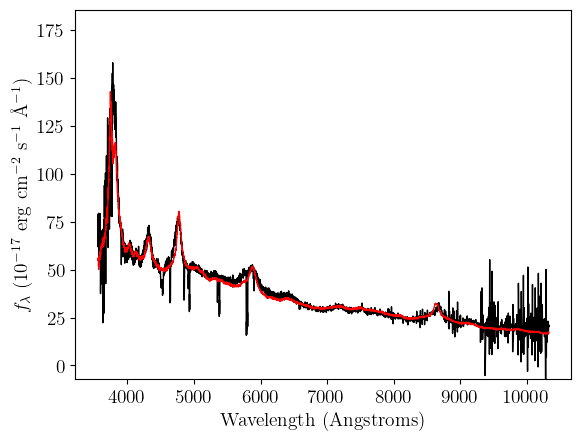

In [16]:
# Let's set sensible limits; the model is better than the data for that
gd = coadd['ivar'] > 0
gdmax = coadd['model'][gd].max()

plt.plot(10.**coadd['loglam'], coadd['flux'], linewidth=1, color='black')
plt.plot(10.**coadd['loglam'], coadd['model'], linewidth=1, color='red')
plt.ylim(np.array([-0.05, 1.3]) * gdmax)

plt.xlabel(r'\rm Wavelength (Angstroms)')
plt.ylabel(r'$f_\lambda$ \rm ($10^{-17}$ erg cm$^{-2}$ s$^{-1}$ \AA$^{-1}$)')

We have three visits so we can compare them.

In [17]:
boss_visits = []
mjds = []
for file in spectrum_files[:10]:
    spec_hdulist = astropy.io.fits.open(file)
    visit = np.array(spec_hdulist['COADD'].data)
    boss_visits.append(visit)
    mjds.append(spec_hdulist[0].header['MJD'])

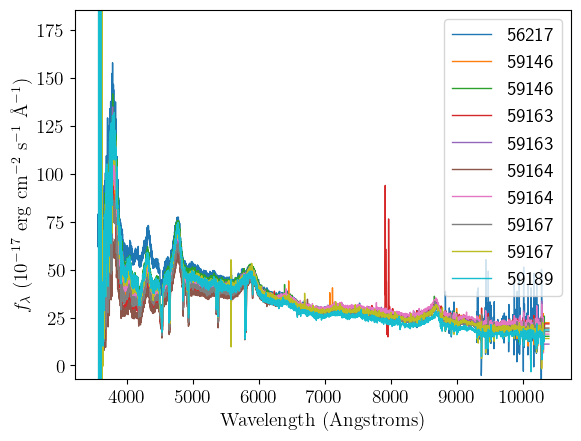

In [18]:
# Let's set sensible limits; the model is better than the data for that
allmax = 0.0
for mjd, visit in zip(mjds, boss_visits):
    if 'ivar' in visit.dtype.names: ## if lowercase exists...
        ivar = visit['ivar']
        model = visit['model']
        loglam = visit['loglam']
        flux = visit['flux']
    else: ## if uppercase exists...
        ivar = visit['IVAR']
        model = visit['MODEL']
        loglam = visit['LOGLAM']
        flux = visit['FLUX']
        
    
    gd = ivar > 0
    gdmax = model[gd].max()
    if(gdmax > allmax):
        allmax = gdmax

    plt.plot(10.**loglam, flux, linewidth=1, label=str(mjd))

plt.ylim(np.array([-0.05, 1.3]) * allmax)
plt.xlabel(r'\rm Wavelength (Angstroms)')
plt.ylabel(r'$f_\lambda$ \rm ($10^{-17}$ erg cm$^{-2}$ s$^{-1}$ \AA$^{-1}$)')
plt.legend()

# --------------- LAB 2 ----------------

In [19]:
## Copied from day 5 tutorial:
# new ra/dec for quasar instead of galaxy
center_ra = [35.25]
center_dec = [0.0]

center_coords = astropy.coordinates.SkyCoord(center_ra, center_dec, unit='deg', frame='icrs')

unique_sdss_id, unique_indx = np.unique(allspec['sdss_id'], return_index=True)
unique_ra = allspec['ra'][unique_indx]
unique_dec = allspec['dec'][unique_indx]

isfinite = np.isfinite(unique_ra) & np.isfinite(unique_dec)
unique_indx = unique_indx[isfinite]
unique_ra = unique_ra[isfinite]
unique_dec = unique_dec[isfinite]

unique_coords = astropy.coordinates.SkyCoord(unique_ra, unique_dec, unit='deg', frame='icrs')

# Matching the catalog to center point
indx, sep, _ = unique_coords.match_to_catalog_sky(center_coords)

In [20]:
## Copied from day 5 tutorial:
# Find objects within 0.5 degrees of the center
radius = 0.5 
selection = np.where(sep.deg < radius)[0]

# This gives the indices of the unique objects in that area
sample_indices = unique_indx[selection]
sample_ids = unique_sdss_id[selection]

print(f"Found {len(sample_ids)} unique objects in this area.")

Found 392 unique objects in this area.


In [21]:
## Copied from day 5 tutorial (adjusted for specLite requirements):
spectrum_files = []

for idx in sample_indices:
    spec_id = allspec['sdss_id'][idx]
    mjd = allspec['mjd'][idx]
    # Add the missing keys required by specLite
    cat_id = allspec['catalogid'][idx]
    field_id = allspec['fps_field'][idx]
    run2d = 'v6_1_3' 
    
    # Build the path with all required arguments
    file_path = sdss_path.full('specLite', sdss_id=spec_id, mjd=mjd, run2d=run2d, 
                               catalogid=cat_id, fieldid=field_id)
    spectrum_files.append(file_path)

print(f"Generated {len(spectrum_files)} file paths.")
print(f"Example path: {spectrum_files[0]}")

Generated 392 file paths.
Example path: /home/idies/workspace/sdss_sas/dr19/spectro/boss/redux/v6_1_3/spectra/lite/104567/59957/spec-104567-59957-27021603120990782.fits


In [22]:
gold_mine_spectra = []

# Get indices where the ID is valid
valid_ids = np.where(allspec['sdss_id'] > 0)[0]

print(f"Checking {len(valid_ids)} valid entries for science quality...")

# Check from the middle of the file to avoid the empty start
start_index = len(valid_ids) // 2 

for i in range(start_index, start_index + 2000):
    idx = valid_ids[i]
    try:
        spec_id = allspec['sdss_id'][idx]
        mjd = allspec['mjd'][idx]
        cat_id = allspec['catalogid'][idx]
        field_id = allspec['fps_field'][idx]
        
        # Try both rversions if one fails
        for run2d in ['v6_1_3', 'v6_1_1']:
            path = sdss_path.full('specLite', sdss_id=spec_id, mjd=mjd, 
                                  run2d=run2d, catalogid=cat_id, fieldid=field_id)
            
            if os.path.exists(path):
                with astropy.io.fits.open(path) as hdul:
                    data = hdul[2].data[0]
                    z = data['Z']
                    sn = data['SN_MEDIAN_ALL']
                    obj_class = str(data['CLASS']).strip()
                    
                    if (z > 1.5) and (sn > 5) and ('QSO' in obj_class):
                        gold_mine_spectra.append(path)
                        print(f"SUCCESS! Found #{len(gold_mine_spectra)}: z={z:.2f}, SN={sn:.1f}, Class={obj_class}")
                        break # Found it, move to next file
    except:
        continue

    if len(gold_mine_spectra) >= 10:
        break

print(f"\nFinal Results: {len(gold_mine_spectra)} Gold Mine spectra found.")

Checking 6983061 valid entries for science quality...
SUCCESS! Found #1: z=1.80, SN=10.8, Class=QSO
SUCCESS! Found #2: z=1.86, SN=5.5, Class=QSO
SUCCESS! Found #3: z=1.65, SN=10.5, Class=QSO
SUCCESS! Found #4: z=2.18, SN=8.3, Class=QSO
SUCCESS! Found #5: z=2.65, SN=14.7, Class=QSO
SUCCESS! Found #6: z=1.83, SN=5.5, Class=QSO
SUCCESS! Found #7: z=2.12, SN=6.6, Class=QSO
SUCCESS! Found #8: z=1.61, SN=8.9, Class=QSO
SUCCESS! Found #9: z=3.39, SN=5.8, Class=QSO
SUCCESS! Found #10: z=2.00, SN=6.7, Class=QSO

Final Results: 10 Gold Mine spectra found.


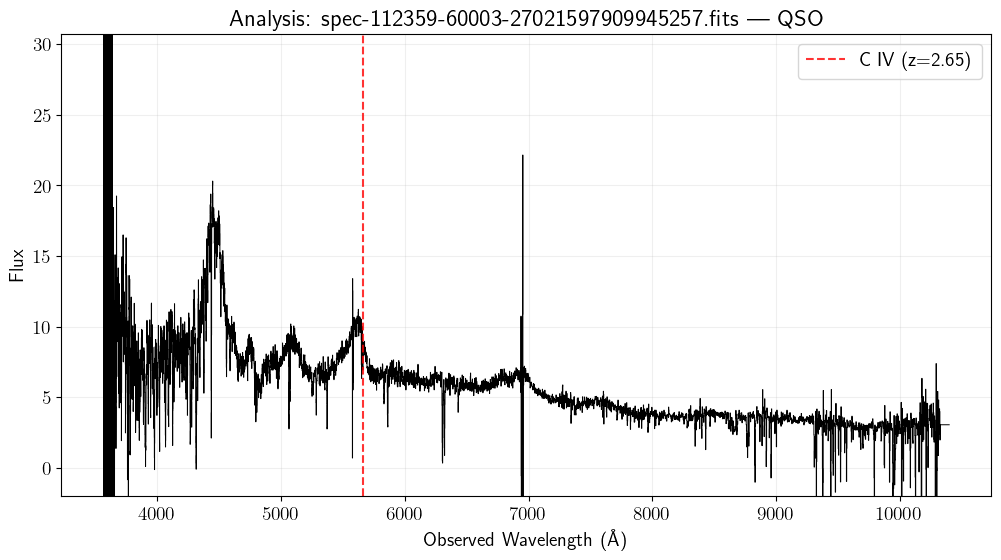

Plotted spec-112359-60003-27021597909945257.fits with Redshift 2.6518


In [23]:
# Choose which to look at (0-9)
file_index = 4
file_path = gold_mine_spectra[file_index]

with astropy.io.fits.open(file_path) as hdul:
    # Pull spectrum data
    spec_data = hdul[1].data 
    flux = spec_data['flux']
    wavelength = 10**spec_data['loglam']
    
    # Pull the exact redshift and class
    science_table = hdul[2].data[0]
    z_actual = science_table['Z']
    obj_class = str(science_table['CLASS']).strip()
    
    # Calculate where C IV should be
    civ_obs = 1549.48 * (1 + z_actual)
    
    # Set the y-axis limits to ignore noise spikes
    ymax = np.percentile(flux, 95) * 2.5
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.step(wavelength, flux, where='mid', color='black', lw=0.7)
    plt.axvline(civ_obs, color='red', linestyle='--', alpha=0.8, label=f'C IV (z={z_actual:.2f})')
    
    # Formatting title
    fname = os.path.basename(file_path)
    plt.title(f"Analysis: {fname} | {obj_class}")
    
    plt.xlabel("Observed Wavelength (Å)")
    plt.ylabel("Flux")
    plt.ylim(-2, ymax) 
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

print(f"Plotted {fname} with Redshift {z_actual:.4f}")

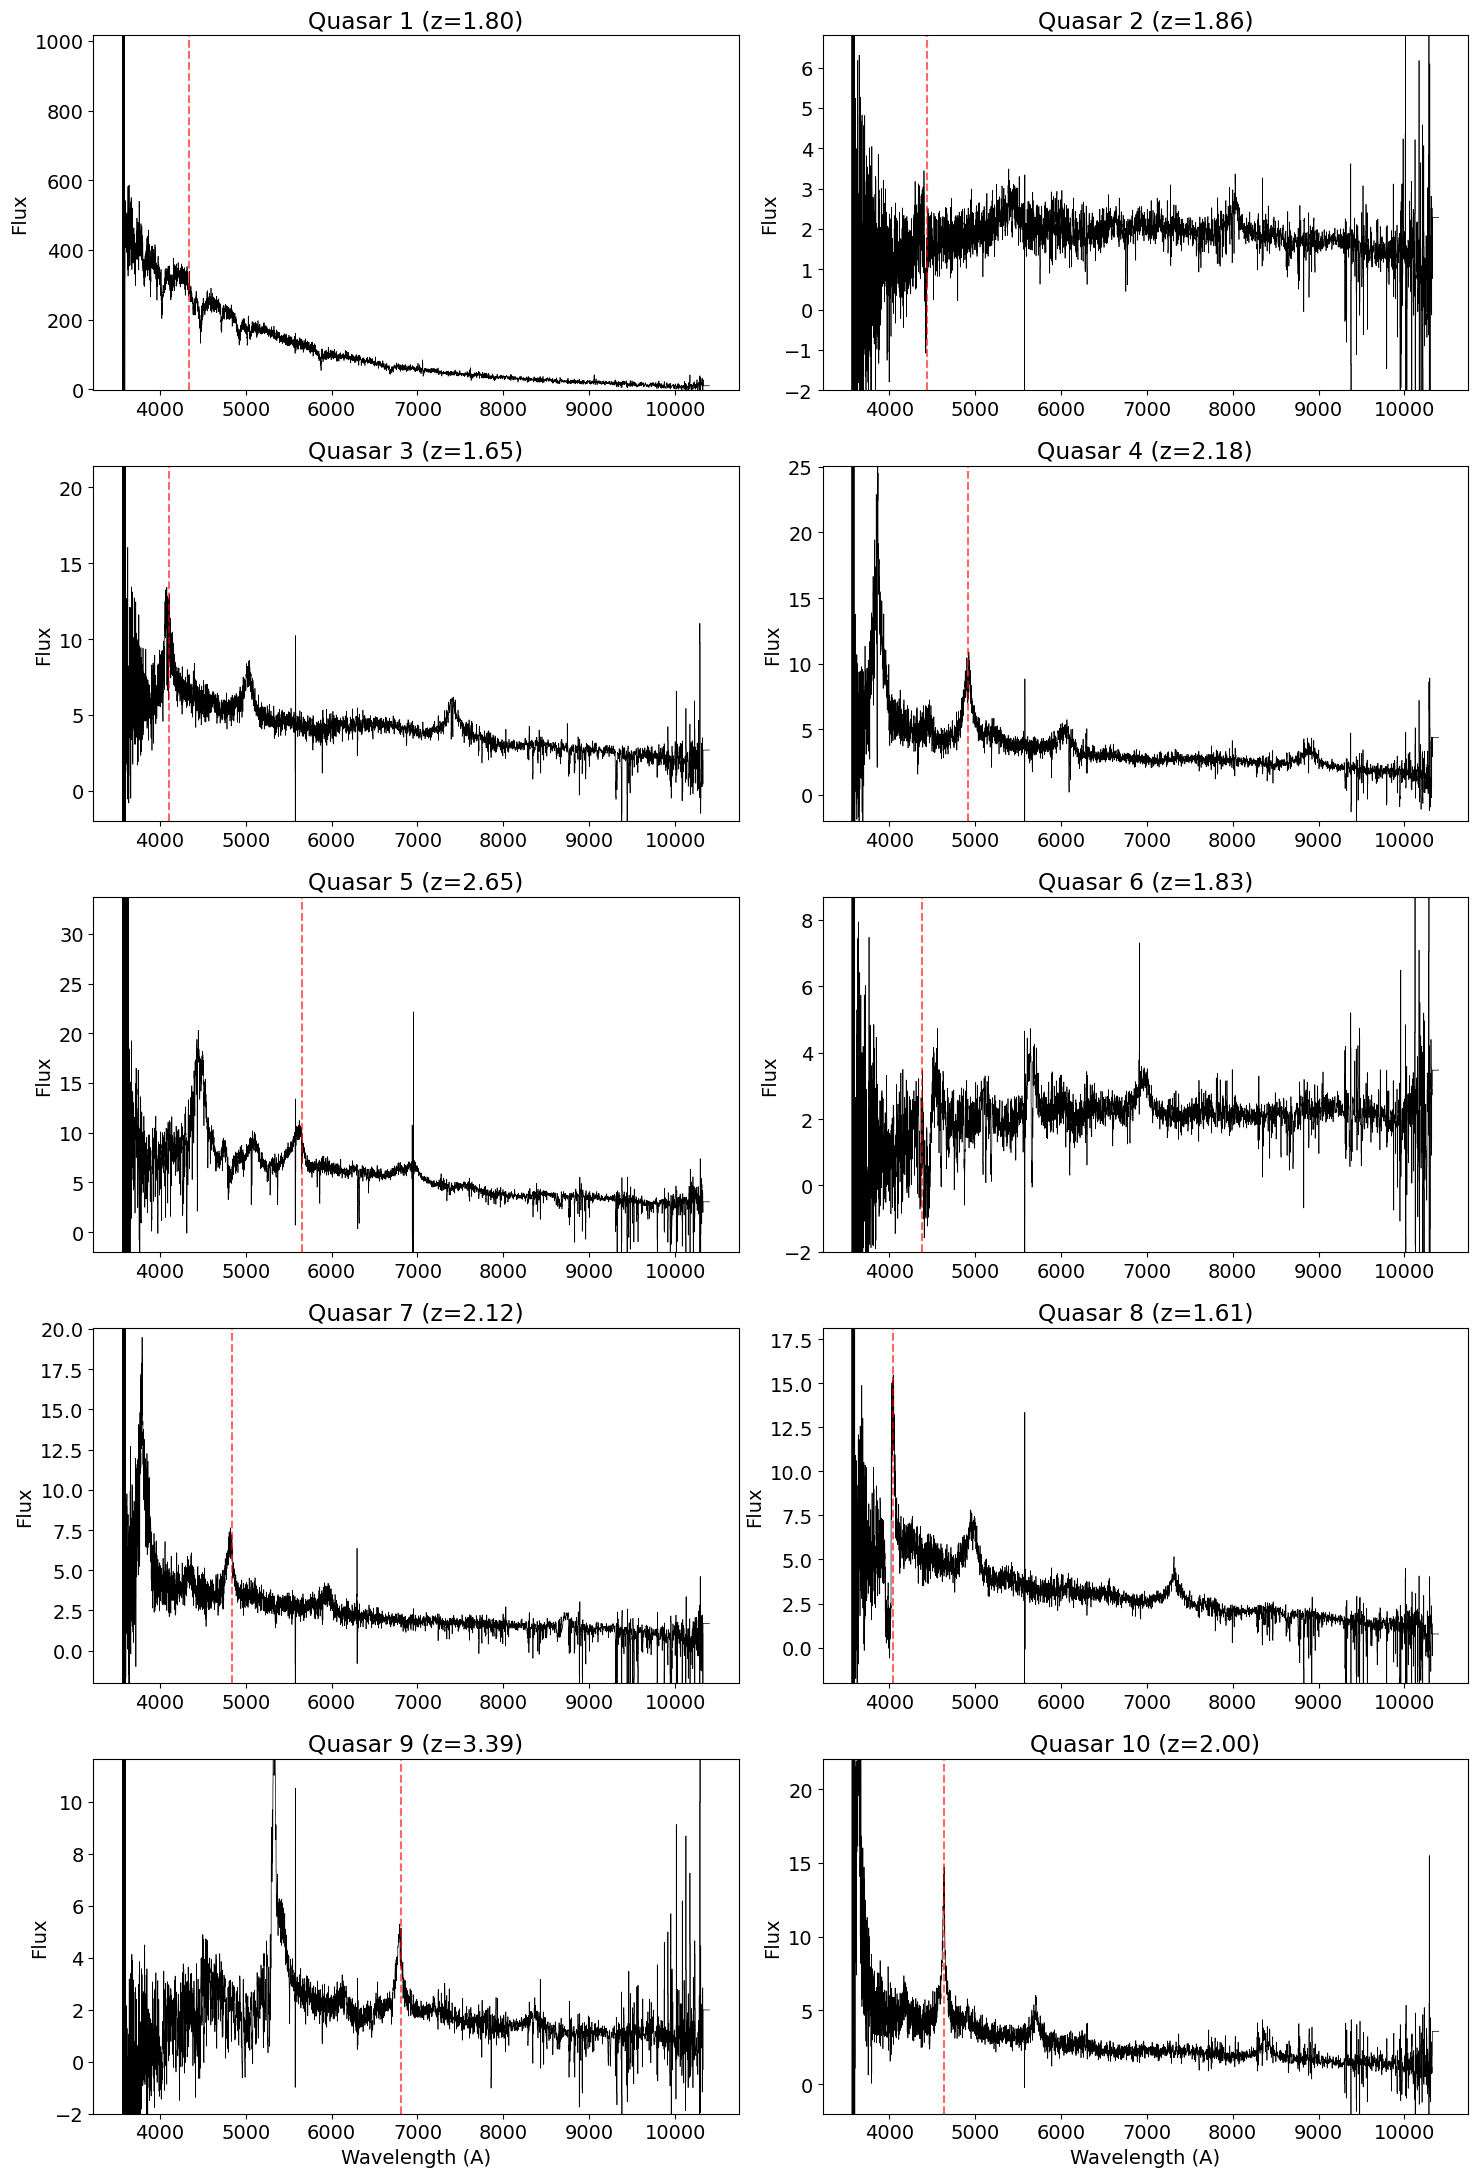

In [24]:
plt.rcParams['text.usetex'] = False # Ensures Matplotlib doesn't crash on special characters like #

fig, axes = plt.subplots(5, 2, figsize=(15, 22))
axes = axes.flatten()

for i, path in enumerate(gold_mine_spectra):
    with astropy.io.fits.open(path) as hdul:
        data = hdul[1].data
        z = hdul[2].data['Z'][0] 
        
        flux = data['flux']
        wave = 10**data['loglam']
        civ_obs = 1549.48 * (1 + z)
        
        # Individual y-limit for each plot to handle different brightnesses
        ymax = np.percentile(flux, 96) * 2.5
        
        ax = axes[i]
        ax.step(wave, flux, color='black', lw=0.5)
        ax.axvline(civ_obs, color='red', linestyle='--', alpha=0.6)
        
        # Removed the "#" character for latex issues
        ax.set_title(f"Quasar {i+1} (z={z:.2f})")
        
        ax.set_ylim(-2, ymax)
        ax.set_ylabel("Flux")
        if i >= 8: ax.set_xlabel("Wavelength (A)")

plt.tight_layout()
plt.show()

### Did the "Fit" Work Successfully?

### For the majority, especially Quasars 4, 5, 7, 8, 9, and 10, the red dashed line aligns with the center of a broad emission peak. Quasar 1 and Quasar 2 show less obvious peaks. In Quasar 2, the signal-to-noise is low enough that while a peak exists near the red line, it is "noisier," making the parameter less certain than in a clear case like Quasar 9.

### Emission Line Width and Trends

### Quasar 5 has a very broad peak compared to Quasar 10. This suggests differences in the velocity of gas surrounding the different black holes. As the independent variable (Redshift z) increases, the emission lines shift toward the right (longer wavelengths), which is expected for cosmological redshift. 